## Task 1: Import Libraries and Modules

In [469]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import joblib


## Task 2: Load the Dataset

In [470]:
df=pd.read_csv('datafile.csv')
df.head()
df.shape

(48204, 9)

## Task 3: Remove Duplicate Values

In [471]:
df.duplicated().sum()

np.int64(17)

In [472]:
df.drop_duplicates(inplace=True)
df.head()
df.dtypes

traffic_volume           int64
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
dtype: object

## Task 4: Create a Histogram of Traffic Volume

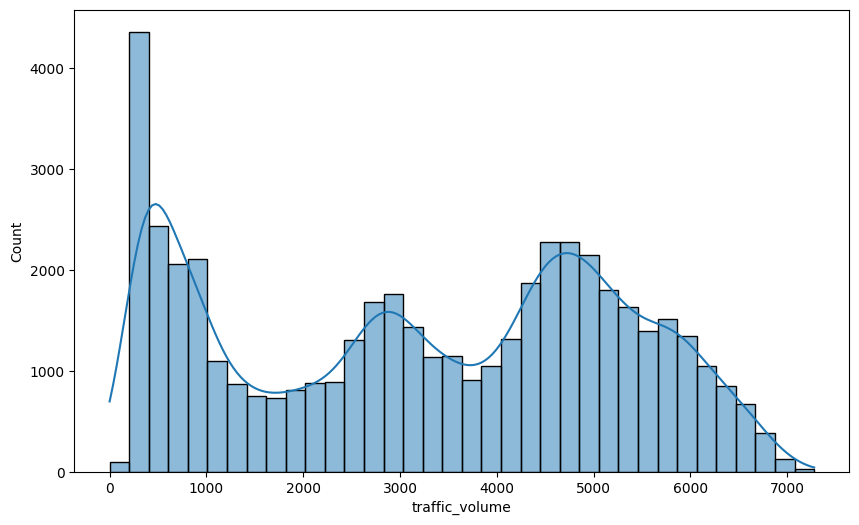

In [473]:
plt.figure(figsize=(10,6))
sns.histplot(df,x=df['traffic_volume'],kde=True)
plt.show()

## Task 5: Get the Date and Time

In [474]:
df['date_time']=pd.to_datetime(df['date_time'],format="mixed")

In [475]:
df.insert(df.shape[1],'day',df['date_time'].apply(lambda d : d.day_name()))

In [476]:
df.insert(df.shape[1],'month',df['date_time'].apply(lambda d : d.month))

In [477]:
df.insert(df.shape[1],'year',df['date_time'].apply(lambda d : d.year))

In [478]:
df.insert(df.shape[1],'hour',df['date_time'].apply(lambda d : d.hour))

In [479]:
df.drop(columns=["date_time"],inplace=True)

In [480]:
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,day,month,year,hour
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,Friday,2,2012,9
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,Friday,2,2012,10
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,Friday,2,2012,11
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,Friday,2,2012,12
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,Friday,2,2012,13


## Task 6: Convert Categorical Columns to Numerical

In [481]:
df.dtypes

traffic_volume           int64
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
day                     object
month                    int64
year                     int64
hour                     int64
dtype: object

In [482]:
categorical_cols=list(set(df.select_dtypes(include='object')))
df=pd.get_dummies(df,columns=categorical_cols)

## Task 7: Create Input and Output Parameters

In [483]:
X=df.drop(columns=["traffic_volume"])
Y=df["traffic_volume"]

## Task 8: Split the Training and Testing Data

In [484]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.15,random_state=123,shuffle=True)

## Task 9: Build the Models

In [485]:
models={
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor()
}

In [486]:
df.dtypes

traffic_volume                                           int64
temp                                                   float64
rain_1h                                                float64
snow_1h                                                float64
clouds_all                                               int64
                                                        ...   
weather_description_thunderstorm with heavy rain          bool
weather_description_thunderstorm with light drizzle       bool
weather_description_thunderstorm with light rain          bool
weather_description_thunderstorm with rain                bool
weather_description_very heavy rain                       bool
Length: 75, dtype: object

## Task 10: Train the Models

In [487]:
for key,value in models.items():
    models[key]=value.fit(X_train,y_train)

## Task 11: Evaluate the Models

In [488]:
predictions={}
for key,value in models.items():
    predictions[key]=value.predict(X_test)

In [490]:
r2_score_list=[]
mean_squarred_list=[]

for key,value in predictions.items():
    print(key)
    r2_score_list.append(r2_score(y_true=y_test,y_pred=value))
    mean_squarred_list.append(mean_squared_error(y_true=y_test,y_pred=value))

LinearRegression
DecisionTreeRegressor
RandomForestRegressor


In [491]:
r2_score_list

[0.15484886412932863, 0.7858527839629857, 0.8783436602727144]

## Task 12: Save the Models

In [562]:
for key,value in models.items():
    joblib.dump(value,key+'.sav')

## Task 13: Load and Use the Models